# Assignment 2

## Imports

In [19]:
import torch
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm.notebook import trange


Restrictions (Important)
For the entire assignment:

Allowed:
   * torch.Tensor operations
   * loss.backward()

Not allowed:
   * torch.optim.*
   * torch.nn.Linear (and generally torch.nn layers)
   * high-level loss modules (nn.MSELoss, etc.) — compute MSE manually
   * high-level training wrappers (Lightning, fastai, Trainer APIs)

# Task 1 — Multivariate Linear Regression + Manual Training Loop (3 pts)

We consider the model:

$$
\hat y = XW+b
$$


Where:

* $ X \in \mathbb R^{N×d} $


* $W \in \mathbb R^{d×1}$
* $b \in \mathbb R$

### Requirements


1. Prepare a dataset with **at least 300 samples** and **at least 3 features**:
   * Option A: use a real dataset (recommended), e.g. **[California Housing](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)** (you may use `sklearn.datasets.fetch_california_housing()` only for loading data, not modeling),
   * Option B: generate synthetic data with d ≥ 3.
2. Split data into **train / validation** (e.g., 80% / 20%).
3. Normalize features using statistics from the training set:

$$
X' = \frac{X-\mu}{\sigma}
$$


4. Initialize parameters:

* `W ~ N(0,1)` (shape `d x 1`)
* `b ~ N(0,1)` (scalar)

  with `requires_grad=True`.


5. Implement:

* forward pass,
* **MSE loss manually**:

$$
MSE = \frac{1}{N} \sum_{i=1}^{N} \left(\hat y_i-y_i\right)^2
$$

* training loop for 200–1000 epochs,
* manual gradient descent update using `torch.no_grad()`:
  * update `W`, `b`,
  * then reset gradients correctly.


6. Plot:

* training loss vs epoch,
* validation loss vs epoch.

In [20]:
X, y = fetch_california_housing(return_X_y=True)

In [21]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.8, random_state=42)

In [22]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train_normalized = torch.tensor((X_train - mean) / std, dtype=torch.float32)
X_val_normalized = torch.tensor((X_val - mean) / std, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [23]:
W = torch.randn((8, 1), requires_grad=True)
b = torch.randn(1, requires_grad=True)

In [24]:
alpha = 1e-3
epochs = 50

training_loss = []
validation_loss = []

for epoch in trange(epochs):
    preds = X_train_normalized @ W + b
    MSE = ((preds - y_train) ** 2).mean()
    training_loss.append(MSE.item())

    with torch.no_grad():
        val_preds = X_val_normalized @ W + b
        val_MSE = ((val_preds - y_val) ** 2).mean()
        validation_loss.append(val_MSE.item())

    MSE.backward()

    with torch.no_grad():
        W -= alpha * W.grad
        b -= alpha * b.grad

    W.grad = None
    b.grad = None

  0%|          | 0/50 [00:00<?, ?it/s]

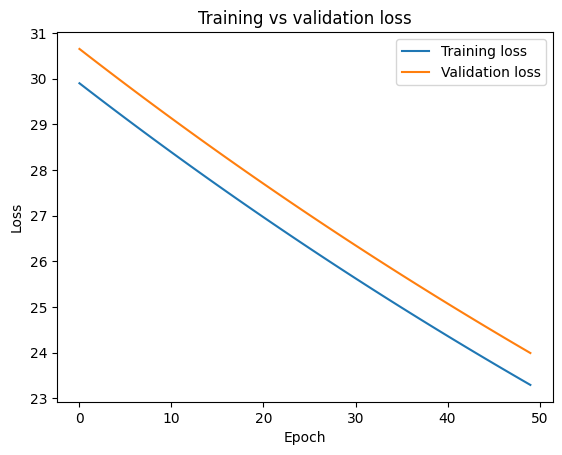

In [25]:
plt.plot(training_loss, label="Training loss")
plt.plot(validation_loss, label="Validation loss")
plt.title('Training vs validation loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

Required Explanation (Markdown)
* Why do we need torch.no_grad() during parameter update?
* Why must we reset gradients each iteration?
* Why does feature normalization typically help optimization?

* Torch.no_grad() is needed because pytorch would include weights as part of gradient graph and this would corrupt our gradient.
* We reset gradients each iteration because we don't want previous gradients to influence new gradients. Pytorch accumulates gradients by default.
* Feature normalization help because it makes loss surface more spherical. Without it, it is more elongated.

# Task 2 — Closed-Form Solution (Normal Equation) (2 pts)

⚠ **This task is a direct continuation of Task 1.**

You must use:

* The **same dataset**
* The **same train/validation split**
* The **same feature normalization**
* The **same training set** for computing parameters

In Task 1, you trained the model using **gradient descent**.

In this task, you will compute the **analytical solution** for linear regression and compare it to the gradient descent solution.


Recall that for linear regression with MSE loss, the optimal parameters can be obtained by solving:

$$
W^* = (X^TX)^{-1} X^T y
$$

You may use:

* `torch.linalg.solve` or `torch.linalg.pinv`

It is recommended to include the bias term by augmenting the input matrix with a column of ones.

### Requirements


1. Compute *W* (and *b* if you separate it).
2. Compute training and validation MSE for:
   * Gradient Descent solution
   * Closed-form solution
3. Compare the results.

In [26]:
X_train_normalized_bias = torch.column_stack((X_train_normalized, torch.ones(X_train_normalized.shape[0], 1)))
X_val_normalized_bias = torch.column_stack((X_val_normalized, torch.ones(X_val_normalized.shape[0], 1)))

In [27]:
cf_W = torch.linalg.solve(X_train_normalized_bias.T @ X_train_normalized_bias, X_train_normalized_bias.T @ y_train)

In [28]:
cf_train_preds = X_train_normalized_bias @ cf_W
cf_train_mse = ((cf_train_preds - y_train) ** 2).mean()

cf_val_preds = X_val_normalized_bias @ cf_W
cf_val_mse = ((cf_val_preds - y_val) ** 2).mean()

print(f"Closed-form Train MSE: {cf_train_mse:.4f}")
print(f"Closed-form Val MSE:   {cf_val_mse:.4f}")

print(f"Gradient Train MSE:    {training_loss[-1]:.4f}")
print(f"Gradient Val MSE:      {validation_loss[-1]:.4f}")

Closed-form Train MSE: 0.5471
Closed-form Val MSE:   0.5218
Gradient Train MSE:    23.2950
Gradient Val MSE:      23.9932


Closed-form solution is better and faster in training(at least in this feature space)

### Required Explanation (Markdown)

* When is the closed-form solution feasible, and when is it not?
* Why might gradient descent not match the closed-form result exactly (even on convex problems)?

* It is feasible if the feature space is small and X^T @ X is invertible.
* Closed form returns the best instantly and gradient needs to get enough epochs to do it. Also floating point error.


# Bonus Task — Conditioning & Geometry (+2 pts)

## Part A — Condition Number Analysis

For linear regression with MSE loss, the curvature of the loss surface is determined by $X^TX$.

Compute the **condition number**:

$$
\kappa(X^T X) = \frac{\lambda_{\max}}{\lambda_{\min}},
$$

where

* $⁡\lambda_{\max}$​ is the largest eigenvalue,
* $\lambda_{\min}$​ is the smallest eigenvalue.

### Requirements


1. Compute $\kappa(X^T X)$ using:
   * Raw (non-normalized) features
   * Normalized features (as in Task 1)
2. Compare the values.
3. Discuss:
   * Is the condition number larger without normalization?
   * What does a large condition number indicate?
   * What happens if $\lambda_{\min} \approx 0$ ?

## Part B — Loss Surface Geometry

To understand the shape of the loss function:


1. Select **two parameters** $w_i, w_j$​.
2. Fix all other parameters.
3. Evaluate the loss on a grid of values for $w_i, w_j$​.
4. Plot contour lines of the loss surface.

Repeat for:

* raw features
* normalized features

In [29]:
X_train_raw = torch.tensor(X_train, dtype=torch.float32)

In [30]:
eigenvalues_raw = torch.linalg.eigvalsh(X_train_raw.T @ X_train_raw)
eigenvalues_norm = torch.linalg.eigvalsh(X_train_normalized.T @ X_train_normalized)

In [31]:
kappa_raw = eigenvalues_raw.max() / eigenvalues_raw.min()
kappa_norm = eigenvalues_norm.max() / eigenvalues_norm.min()

print(f'Kappa raw:  {kappa_raw:.4f}')
print(f'Kappa norm: {kappa_norm:.4f}')

Kappa raw:  124032552.0000
Kappa norm: 55.1096


Condition number is larger without normalization by a lot.

This number means that some features dominate others. (Loss function is stretched elipse)

If lambda min is near 0 then this will explode near infinity.

In [32]:
cf_W_raw = torch.linalg.solve(
    X_train_raw.T @ X_train_raw,
    X_train_raw.T @ y_train
)

cf_W_norm_nobias = torch.linalg.solve(
    X_train_normalized.T @ X_train_normalized,
    X_train_normalized.T @ y_train
)

w0_offsets = torch.linspace(-2, 2, 100)
w1_offsets = torch.linspace(-2, 2, 100)
W0_off, W1_off = torch.meshgrid(w0_offsets, w1_offsets, indexing='ij')

In [33]:
def compute_loss_grid(X, y, w_center, W0_off, W1_off, i=0, j=1):
    loss_grid = torch.zeros_like(W0_off)
    for a in range(W0_off.shape[0]):
        for b in range(W0_off.shape[1]):
            W_temp = w_center.clone()
            W_temp[i] = w_center[i] + W0_off[a, b]
            W_temp[j] = w_center[j] + W1_off[a, b]
            preds = X @ W_temp
            loss_grid[a, b] = ((preds - y) ** 2).mean()
    return loss_grid

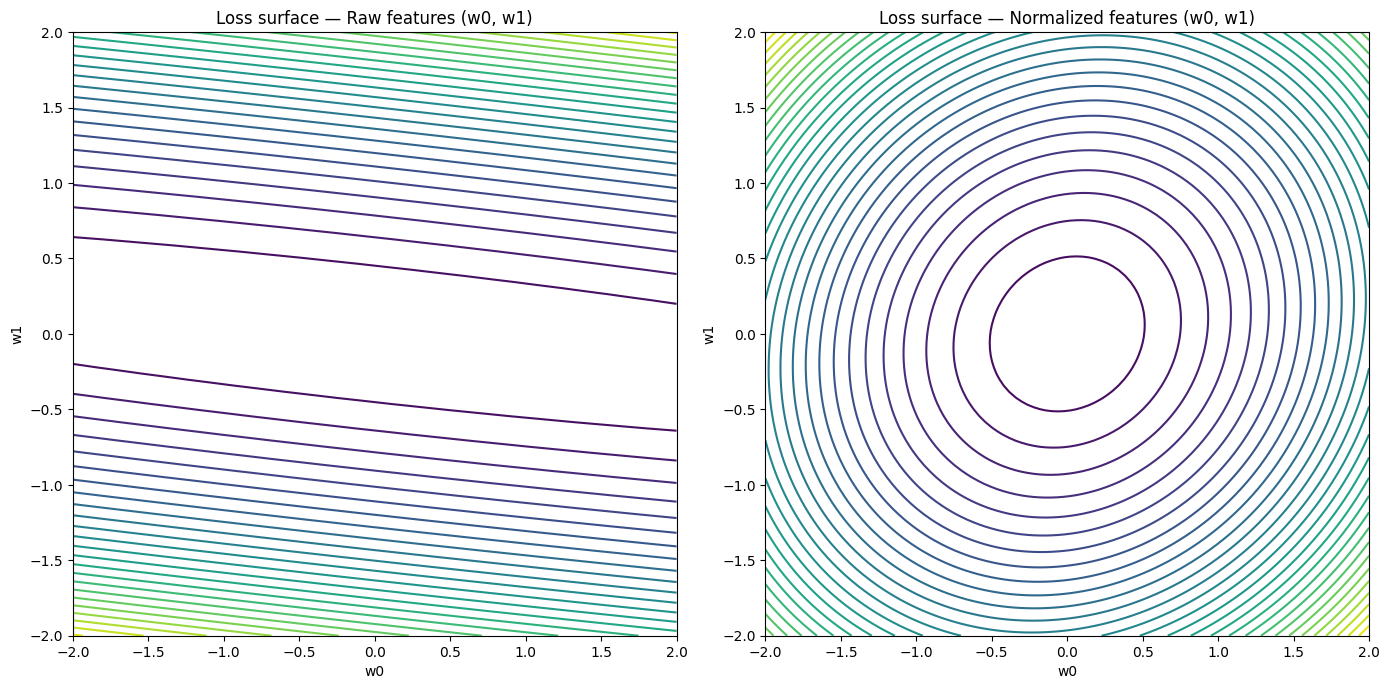

In [34]:
loss_raw = compute_loss_grid(X_train_raw, y_train, cf_W_raw, W0_off, W1_off)
loss_norm = compute_loss_grid(X_train_normalized, y_train, cf_W_norm_nobias, W0_off, W1_off)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

cp1 = ax1.contour(W0_off.numpy(), W1_off.numpy(), loss_raw.numpy(), levels=30)
ax1.set_title('Loss surface — Raw features (w0, w1)')
ax1.set_xlabel('w0')
ax1.set_ylabel('w1')
ax1.set_aspect('equal')

cp2 = ax2.contour(W0_off.numpy(), W1_off.numpy(), loss_norm.numpy(), levels=30)
ax2.set_title('Loss surface — Normalized features (w0, w1)')
ax2.set_xlabel('w0')
ax2.set_ylabel('w1')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

### Required Analysis

Discuss (in Markdown):

* What is the shape of the contours without normalization?
* What is the shape after normalization?
* Are they circular or elongated?
* How does this relate to the condition number?

* Elliptical
* More like a circle
* One is elongated and the other circular
* This condition number determines the shape

# Task 3 — Optimization Study (2 pts)

Run controlled experiments to study optimization behavior.

### Requirements

Train the same model while changing only the **learning rate**.

Test at least 3 learning rates:

* **too small** (slow learning)
* **reasonable**
* **too large** (divergence or oscillations)

For each learning rate:

* plot training loss curve,
* report final train/val MSE.

Additionally, track and plot the gradient norm per epoch:

$$
\left \| \nabla_W L \right\|_2
$$

  0%|          | 0/500 [00:00<?, ?it/s]

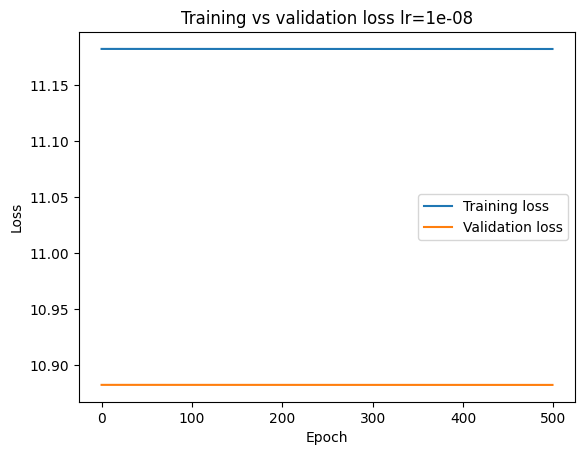

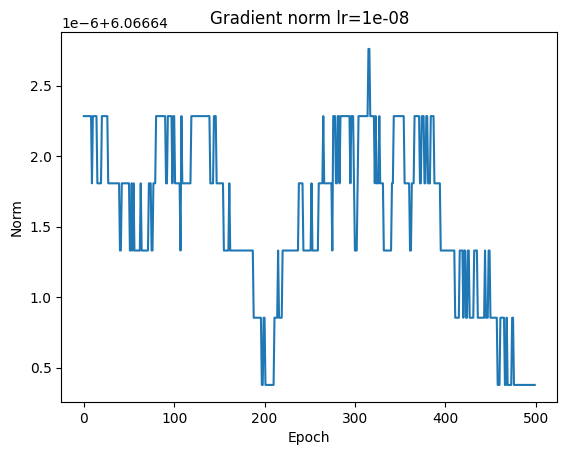

Alpha:           1e-08
Final Train MSE: 11.1825
Final Val MSE:   10.8826


  0%|          | 0/500 [00:00<?, ?it/s]

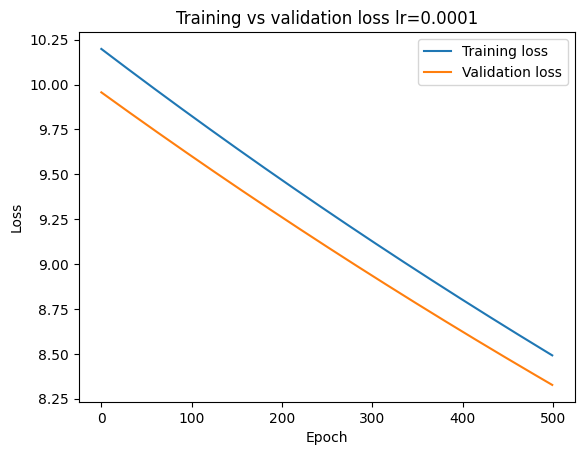

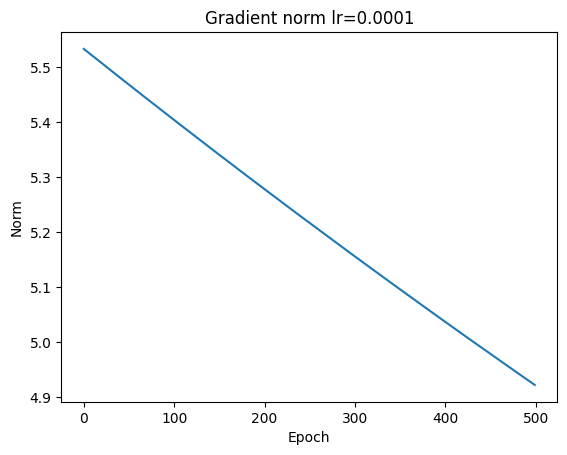

Alpha:           0.0001
Final Train MSE: 8.4915
Final Val MSE:   8.3268


  0%|          | 0/500 [00:00<?, ?it/s]

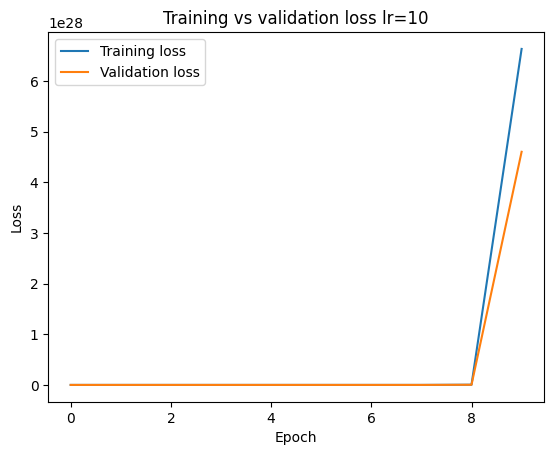

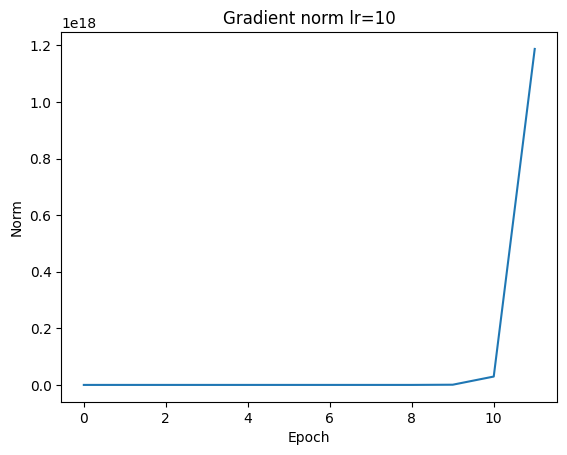

Alpha:           10
Final Train MSE: nan
Final Val MSE:   nan


In [35]:
alphas = [1e-8, 1e-4, 10]
epochs = 500

for alpha in alphas:
    W = torch.randn((8, 1), requires_grad=True)
    b = torch.randn(1, requires_grad=True)

    training_loss = []
    validation_loss = []
    gradient_norms = []

    for epoch in trange(epochs):
        preds = X_train_normalized @ W + b
        MSE = ((preds - y_train) ** 2).mean()
        training_loss.append(MSE.item())

        with torch.no_grad():
            val_preds = X_val_normalized @ W + b
            val_MSE = ((val_preds - y_val) ** 2).mean()
            validation_loss.append(val_MSE.item())

        MSE.backward()
        gradient_norms.append(W.grad.norm().item())

        with torch.no_grad():
            W -= alpha * W.grad
            b -= alpha * b.grad

        W.grad = None
        b.grad = None

    plt.plot(training_loss, label="Training loss")
    plt.plot(validation_loss, label="Validation loss")
    plt.title(f'Training vs validation loss lr={alpha}')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

    plt.plot(gradient_norms)
    plt.title(f'Gradient norm lr={alpha}')
    plt.ylabel('Norm')
    plt.xlabel('Epoch')
    plt.show()

    print(f'Alpha:           {alpha}')
    print(f'Final Train MSE: {training_loss[-1]:.4f}')
    print(f'Final Val MSE:   {validation_loss[-1]:.4f}')

### Required Explanation (Markdown)

* What does divergence look like in the loss curve?
* Explain why too-large learning rate causes instability.
* How does **normalization** affect the range of “reasonable” learning rates?

* lr = 10 example
* Too large lr causes may cause bouncing from one side of minimum to the other.
* Normalization makes the range of "reasonable" learning rates larger. Normalization causes for loss surface to be more spherical and that makes more lr viable for this. Without normalization lr may be to big for one feature and too small for other

# Deliverables Checklist

Your notebook must contain:

- [ ] dataset preparation + split,
- [ ] normalization step,
- [ ] model implementation (forward + MSE),
- [ ] training loop with manual updates,
- [ ] plots (loss curves, gradient norm),
- [ ] closed-form solution comparison,
- [ ] written answers to required questions.